In [1]:
!pip install kaggle
!kaggle datasets list | head
!export KAGGLE_API_TOKEN=KGAT_e0d4b880e92a4cb6dfff3ca75770a3d3

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.config/kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [2]:
import os

os.environ['KAGGLE_USERNAME'] = 'himajachaluvadi'
os.environ['KAGGLE_KEY'] = 'KGAT_e0d4b880e92a4cb6dfff3ca75770a3d3'
!kaggle datasets download -d dasa7753912/new-paddy-doctor-paddy-disease-classification

Dataset URL: https://www.kaggle.com/datasets/dasa7753912/new-paddy-doctor-paddy-disease-classification
License(s): unknown
100% 2.16G/2.17G [00:14<00:00, 269MB/s]
100% 2.17G/2.17G [00:14<00:00, 160MB/s]


In [3]:
!unzip new-paddy-doctor-paddy-disease-classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: paddy-disease-classification/train_images/hispa/104947.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104955.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104959.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104960.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104967.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104969.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104973.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104976.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104979.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104981.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104985.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104986.jpg  
  inflating: paddy-disease-classification/train_images/hispa/

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2,EfficientNetB0
from sklearn.metrics import classification_report, confusion_matrix


In [5]:
TRAIN_DIR = "/content/paddy-disease-classification/train_images"
TEST_DIR  = "/content/paddy-disease-classification/test_images"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 5


In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)


Found 19131 files belonging to 10 classes.


In [7]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


Found 10407 files belonging to 10 classes.


In [8]:
class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)


Classes: ['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']


In [9]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = models.Sequential([
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=test_ds
)


Epoch 1/5
598/598 ━━━━━━━━━━━━━━━━━━━━ 111s 154ms/step - accuracy: 0.5221 - loss: 1.3955 - val_accuracy: 0.7247 - val_loss: 0.8253
Epoch 2/5
598/598 ━━━━━━━━━━━━━━━━━━━━ 118s 139ms/step - accuracy: 0.7840 - loss: 0.6735 - val_accuracy: 0.8103 - val_loss: 0.6023
Epoch 3/5
598/598 ━━━━━━━━━━━━━━━━━━━━ 82s 138ms/step - accuracy: 0.8405 - loss: 0.5056 - val_accuracy: 0.8515 - val_loss: 0.4690
Epoch 4/5
598/598 ━━━━━━━━━━━━━━━━━━━━ 63s 105ms/step - accuracy: 0.8815 - loss: 0.3778 - val_accuracy: 0.8965 - val_loss: 0.3458
Epoch 5/5
598/598 ━━━━━━━━━━━━━━━━━━━━ 82s 105ms/step - accuracy: 0.9097 - loss: 0.2985 - val_accuracy: 0.9136 - val_loss: 0.2821


In [11]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {test_accuracy:.4f}")


326/326 ━━━━━━━━━━━━━━━━━━━━ 22s 67ms/step - accuracy: 0.9217 - loss: 0.2572
Test Accuracy: 0.9136


In [12]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━

In [13]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))


                          precision    recall  f1-score   support

   bacterial_leaf_blight       0.88      0.87      0.87       479
   bacterial_leaf_streak       0.91      0.98      0.94       380
bacterial_panicle_blight       0.91      0.97      0.94       337
                   blast       0.90      0.94      0.92      1738
              brown_spot       0.88      0.93      0.91       965
              dead_heart       0.95      0.96      0.95      1442
            downy_mildew       0.99      0.74      0.85       620
                   hispa       0.95      0.85      0.90      1594
                  normal       0.89      0.96      0.92      1764
                  tungro       0.90      0.90      0.90      1088

                accuracy                           0.91     10407
               macro avg       0.92      0.91      0.91     10407
            weighted avg       0.92      0.91      0.91     10407



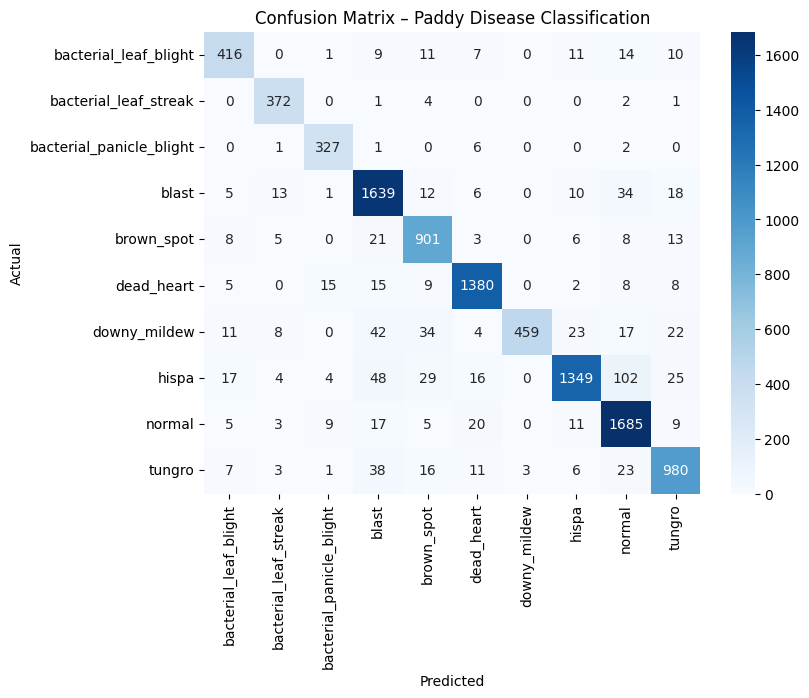

In [14]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Paddy Disease Classification")
plt.show()


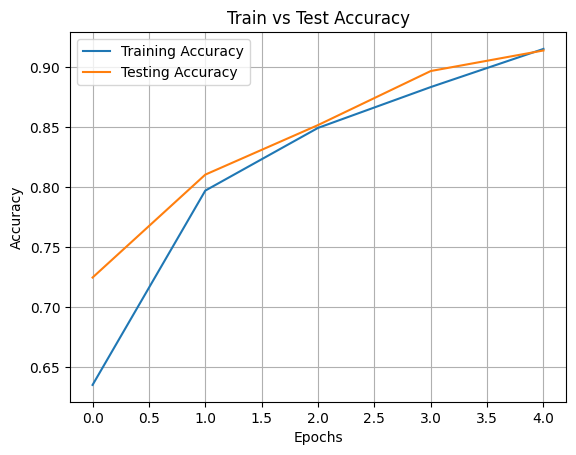

In [15]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Testing Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()


resnet


In [16]:
from tensorflow.keras.applications import ResNet50

In [17]:
base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = models.Sequential([
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [18]:
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)


Epoch 1/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 101s 148ms/step - accuracy: 0.3893 - loss: 1.7576 - val_accuracy: 0.5450 - val_loss: 1.3938
Epoch 2/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 124s 129ms/step - accuracy: 0.6068 - loss: 1.1798 - val_accuracy: 0.6853 - val_loss: 0.9830
Epoch 3/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 98s 164ms/step - accuracy: 0.6806 - loss: 0.9716 - val_accuracy: 0.7308 - val_loss: 0.8306
Epoch 4/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 78s 131ms/step - accuracy: 0.7341 - loss: 0.8253 - val_accuracy: 0.7922 - val_loss: 0.6753
Epoch 5/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 79s 132ms/step - accuracy: 0.7671 - loss: 0.7168 - val_accuracy: 0.8208 - val_loss: 0.5906
Epoch 6/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 93s 156ms/step - accuracy: 0.7904 - loss: 0.6381 - val_accuracy: 0.8518 - val_loss: 0.4912
Epoch 7/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 92s 155ms/step - accuracy: 0.8259 - loss: 0.5477 - val_accuracy: 0.8539 - val_loss: 0.4662
Epoch 8/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 93s 155ms/step - accuracy: 0.8383 - loss:

In [19]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")


326/326 ━━━━━━━━━━━━━━━━━━━━ 29s 90ms/step - accuracy: 0.9090 - loss: 0.3081
Test Accuracy: 0.9106


In [20]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [21]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))


                          precision    recall  f1-score   support

   bacterial_leaf_blight       0.87      0.85      0.86       479
   bacterial_leaf_streak       0.95      0.95      0.95       380
bacterial_panicle_blight       0.92      0.93      0.93       337
                   blast       0.92      0.95      0.93      1738
              brown_spot       0.86      0.87      0.87       965
              dead_heart       0.97      0.93      0.95      1442
            downy_mildew       0.90      0.82      0.86       620
                   hispa       0.92      0.88      0.90      1594
                  normal       0.89      0.95      0.92      1764
                  tungro       0.90      0.89      0.90      1088

                accuracy                           0.91     10407
               macro avg       0.91      0.90      0.91     10407
            weighted avg       0.91      0.91      0.91     10407



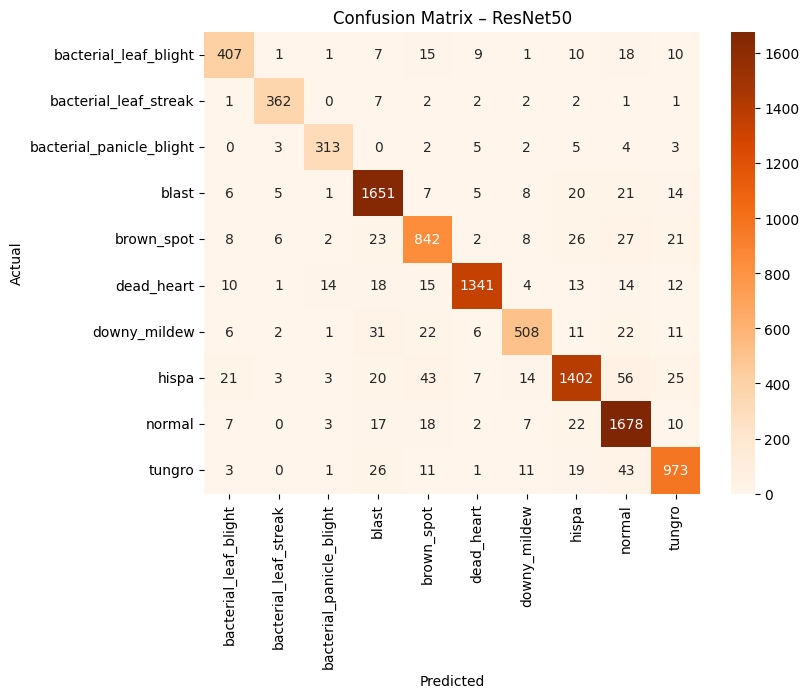

In [22]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            cmap="Oranges",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – ResNet50")
plt.show()


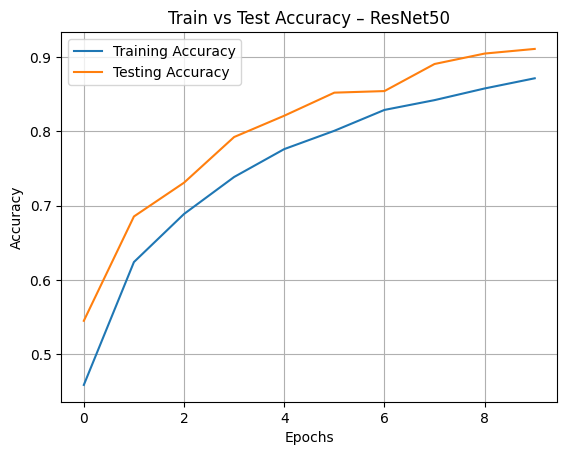

In [23]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Testing Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy – ResNet50")
plt.legend()
plt.grid(True)
plt.show()


In [24]:
model.save("/content/drive/MyDrive/paddy_disease_resnet50.h5")


Xception


In [27]:
TRAIN_DIR = "/content/paddy-disease-classification/train_images"
TEST_DIR  = "/content/paddy-disease-classification/test_images"

IMG_SIZE = (224, 224)   # Xception usually uses 299, but 224 works fine
BATCH_SIZE = 32
EPOCHS = 10


In [28]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)


Found 19131 files belonging to 10 classes.


In [30]:
from tensorflow.keras.applications import Xception
base_model = Xception(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = models.Sequential([
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 7, 7, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,861,480 (79.58 MB)

In [31]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=test_ds
)


Epoch 1/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 166s 237ms/step - accuracy: 0.5060 - loss: 1.6399 - val_accuracy: 0.7685 - val_loss: 0.7186
Epoch 2/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 152s 185ms/step - accuracy: 0.7511 - loss: 0.7474 - val_accuracy: 0.8391 - val_loss: 0.5061
Epoch 3/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 114s 191ms/step - accuracy: 0.8159 - loss: 0.5465 - val_accuracy: 0.9035 - val_loss: 0.3298
Epoch 4/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 116s 195ms/step - accuracy: 0.8523 - loss: 0.4389 - val_accuracy: 0.9270 - val_loss: 0.2554
Epoch 5/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 116s 195ms/step - accuracy: 0.8709 - loss: 0.3791 - val_accuracy: 0.9442 - val_loss: 0.1931
Epoch 6/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 139s 190ms/step - accuracy: 0.8880 - loss: 0.3327 - val_accuracy: 0.9566 - val_loss: 0.1522
Epoch 7/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 116s 194ms/step - accuracy: 0.9020 - loss: 0.2899 - val_accuracy: 0.9657 - val_loss: 0.1289
Epoch 8/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 116s 195ms/step - accuracy: 0.9096 -

In [32]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")


326/326 ━━━━━━━━━━━━━━━━━━━━ 42s 129ms/step - accuracy: 0.9820 - loss: 0.0670
Test Accuracy: 0.9810


In [33]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [34]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))


                          precision    recall  f1-score   support

   bacterial_leaf_blight       0.98      0.98      0.98       479
   bacterial_leaf_streak       0.99      0.99      0.99       380
bacterial_panicle_blight       0.98      1.00      0.99       337
                   blast       0.98      0.99      0.98      1738
              brown_spot       0.97      0.98      0.98       965
              dead_heart       1.00      0.98      0.99      1442
            downy_mildew       0.97      0.98      0.98       620
                   hispa       0.99      0.95      0.97      1594
                  normal       0.97      0.99      0.98      1764
                  tungro       0.97      0.99      0.98      1088

                accuracy                           0.98     10407
               macro avg       0.98      0.98      0.98     10407
            weighted avg       0.98      0.98      0.98     10407



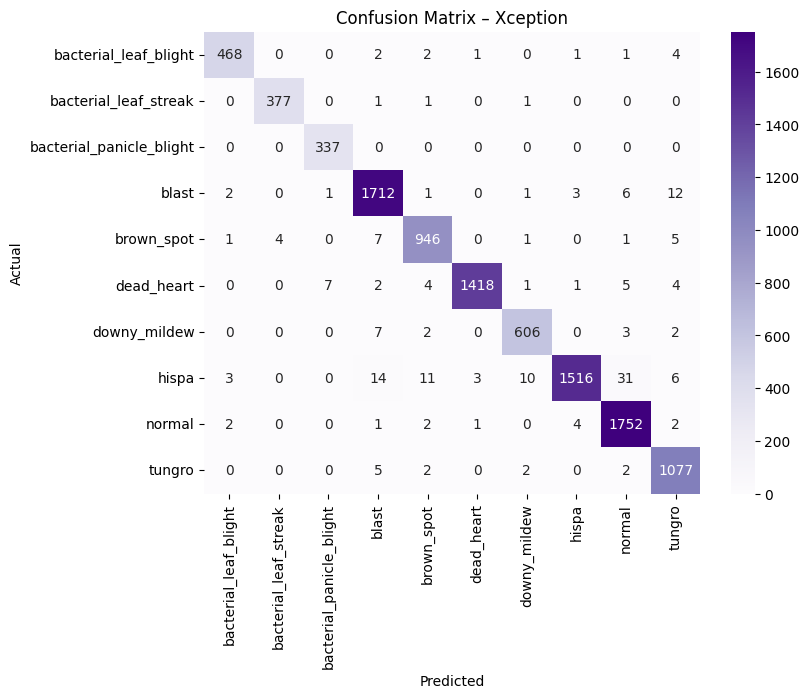

In [35]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            cmap="Purples",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Xception")
plt.show()


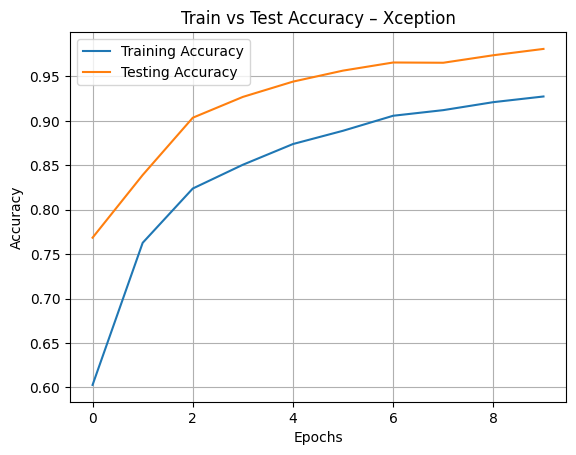

In [36]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Testing Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy – Xception")
plt.legend()
plt.grid(True)
plt.show()


In [37]:
model.save("/content/drive/MyDrive/paddy_disease_xception.h5")


efficientnet

In [53]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = (224, 224)

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)


model = models.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_3 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385,197 (16.73 MB)

 Trainable params: 4,340,614 (16.56 MB)

 Non-trainable params: 44,583 (174.16 KB)

In [46]:
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)


Epoch 1/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 109s 145ms/step - accuracy: 0.5763 - loss: 1.3427 - val_accuracy: 0.8563 - val_loss: 0.4752
Epoch 2/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 108s 108ms/step - accuracy: 0.7952 - loss: 0.6124 - val_accuracy: 0.9011 - val_loss: 0.3250
Epoch 3/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 82s 108ms/step - accuracy: 0.8457 - loss: 0.4671 - val_accuracy: 0.9362 - val_loss: 0.2245
Epoch 4/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 82s 108ms/step - accuracy: 0.8713 - loss: 0.3835 - val_accuracy: 0.9443 - val_loss: 0.1894
Epoch 5/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 82s 109ms/step - accuracy: 0.8899 - loss: 0.3289 - val_accuracy: 0.9601 - val_loss: 0.1395
Epoch 6/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 82s 109ms/step - accuracy: 0.8921 - loss: 0.3126 - val_accuracy: 0.9633 - val_loss: 0.1221
Epoch 7/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 82s 109ms/step - accuracy: 0.9054 - loss: 0.2843 - val_accuracy: 0.9710 - val_loss: 0.1056
Epoch 8/10
598/598 ━━━━━━━━━━━━━━━━━━━━ 65s 108ms/step - accuracy: 0.9193 - loss:

In [47]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")


326/326 ━━━━━━━━━━━━━━━━━━━━ 24s 72ms/step - accuracy: 0.9838 - loss: 0.0581
Test Accuracy: 0.9790


In [48]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


In [49]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))


                          precision    recall  f1-score   support

   bacterial_leaf_blight       0.98      0.99      0.99       479
   bacterial_leaf_streak       0.99      0.99      0.99       380
bacterial_panicle_blight       0.99      1.00      0.99       337
                   blast       0.98      0.98      0.98      1738
              brown_spot       0.95      1.00      0.97       965
              dead_heart       1.00      0.99      1.00      1442
            downy_mildew       0.96      0.96      0.96       620
                   hispa       0.99      0.95      0.97      1594
                  normal       0.98      0.98      0.98      1764
                  tungro       0.96      0.98      0.97      1088

                accuracy                           0.98     10407
               macro avg       0.98      0.98      0.98     10407
            weighted avg       0.98      0.98      0.98     10407



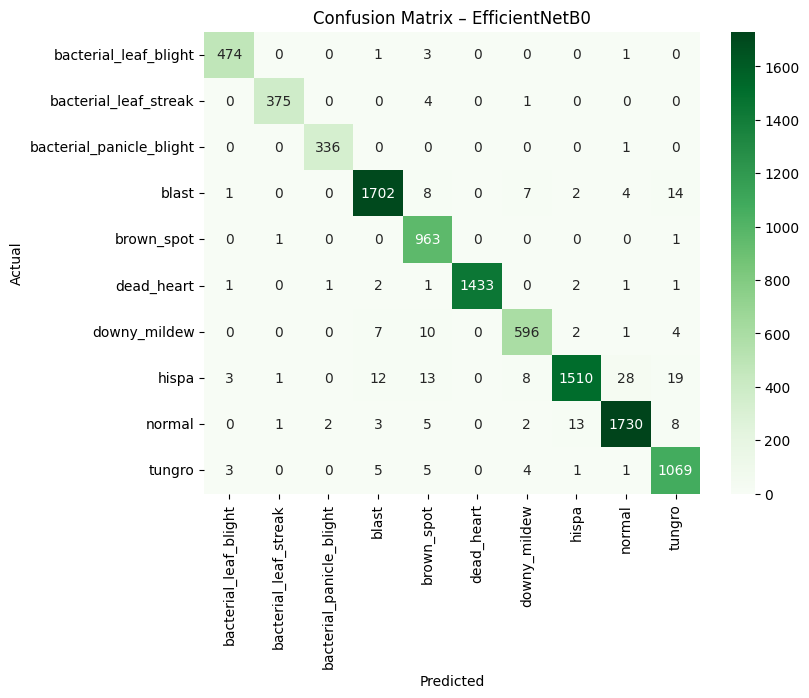

In [50]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            cmap="Greens",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – EfficientNetB0")
plt.show()


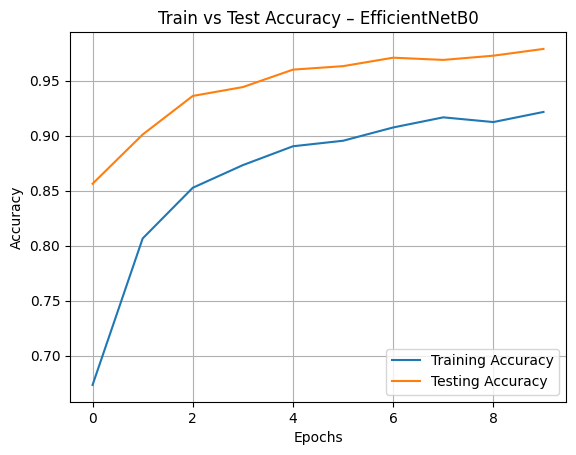

In [51]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Testing Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy – EfficientNetB0")
plt.legend()
plt.grid(True)
plt.show()


In [52]:
model.save("/content/drive/MyDrive/paddy_disease_efficientnetb0.h5")
